<a href="https://colab.research.google.com/github/rafaeldebarros/MVP_machine_learning/blob/main/MVP_ML_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** _RAFAEL SOUZA DE BARROS_  
**Matrícula:** _4052025001449_  
**Data:** _01/07/2026_  
**Dataset:** _Íntegras de Decisões Terminativas e Acórdãos do Diário da Justiça - https://dadosabertos.web.stj.jus.br/dataset/integras-de-decisoes-terminativas-e-acordaos-do-diario-da-justica_  
**Tipo de problema:** _Classificação_  

---

## Observações importantes

O _dataset_ escolhido possui dados das decisões terminativas proferidas pelos Ministros do Superior Tribunal de Justiça e é formado por dois conjunto de dados. O primeiro chamado **metadados**, que contém algumas informações sobre o processo julgado, como número do recurso, nome do Ministro Relator, código do assunto CNJ, desfecho do julgamento, entre outros, disponibilizado em formato JSON. Ainda, há um segundo conjunto de dados, que consiste em arquivos TXT contendo a transcrição das decisões proferidas.

Em virtude da grande quantidade de decisões publicadas (milhares de decisões por dia) e também pela diferença dos assuntos tratadas e da quantidade de Ministros em cada Seção do STJ, optei realizar tratamento prévio do _dataset_ para filtrar apenas as decisões dos Ministros que compõem a 1ª Seção do STJ, a qual julga os processos de Direito Público (Direito Administrativo, Direito Ambiental, Direito Tributário, etc.).

Assim, utilizei todos os dados de decisões terminativas proferidas pelos Ministros que compõem a 1ª Seção do STJ desde o 01/01/2026 até 31/05/2026.


# 1. Definição do problema

## 1.1 Descrição do problema

Nos últimos anos, os Tribunais Superiores brasileiros têm enfrentado um crescimento expressivo no volume de processos, registrando um aumento acumulado de 75,9% no período de 2011 a 2024. Para fazer frente a essa demanda, essas Cortes integraram ferramentas avançadas de Inteligência Artificial aos seus fluxos de trabalho, o que elevou drasticamente a velocidade dos julgamentos. No entanto, essa celeridade impõe um desafio crítico para a gestão da litigância estratégica: acompanhar, mapear e antecipar o posicionamento dinâmico dos Ministros diante de uma enorme pluralidade de temas jurídicos.

Nesse cenário, a incapacidade de antever o desfecho mais provável de recursos baseados em assuntos e teses específicas gera ineficiência operacional, assimetria de informação e tomadas de decisão baseadas em intuição, elevando os riscos financeiros envolvidos no contencioso.

Por conseguinte, há uma necessidade latente de soluções que auxiliem na classificação preditiva desses julgamentos. O modelo preditivo proposto neste MVP visa apoiar a tomada de decisão estratégica, identificando quais matérias e recursos possuem maior probabilidade de êxito ou rejeição nas Cortes Superiores. Essa solução é de direto interesse de grandes litigantes (como entes públicos), conselhos de representação jurídica e escritórios de advocacia de grande porte. A aplicação prática deste modelo visa mitigar custos de conformidade, otimizar alocação de recursos e, em última análise, contribuir para a redução do índice de congestionamento do Poder Judiciário.


## 1.2 Objetivo do MVP

O objetivo deste MVP é desenvolver e avaliar um modelo preditivo de classificação supervisionada capaz de estimar a probabilidade de êxito de um recurso com base no assunto tratado. Para isso, o modelo analisará o padrão das decisões finais proferidas pelos Ministros da 1ª Seção do Superior Tribunal de Justiça (STJ) em um horizonte temporal que compreende de janeiro de 2026 a maio de 2026. O modelo confrontará o desempenho preditivo de teses específicas com as chances gerais de vitória da Corte, servindo como ferramenta analítica para embasar a decisão estratégica de litigar ou abdicar de determinada tese jurídica.


## 1.3 Tipo de problema


**Tipo escolhido:** _Classificação (Supervisionada)_  
**Justificativa:** _O objetivo central do MVP é prever uma categoria discreta (classe), que corresponde ao desfecho do recurso para o recorrente (se será "Favorável", "Desfavorável" ou "Parcial"). Embora o objetivo de negócio mencione "indicar a probabilidade de êxito", essa probabilidade será calculada a partir de modelos probabilísticos de classificação, e não através de uma Regressão numérica contínua tradicional._



## 1.4 Premissas, hipóteses e critérios de sucesso


**Hipóteses iniciais:**
1. _O texto da ementa e da conclusão monocrática possui padrões linguísticos e jargões processuais altamente correlacionados com o desfecho do julgamento e o tema discutido no recurso._
2. _Existe uma variação estatisticamente significativa nas taxas de êxito a depender do Ministro Relator e do assunto do processo, indicando que o perfil do julgador e a tese jurídica são preditores relevantes para o modelo_
3. _A acurácia do modelo de predição de desfecho será significativamente maior se o conjunto de dados for segmentado e treinado especificamente por macro-áreas (ex: Direito Tributário, 1ª Seção do STJ) em vez de um modelo genérico para todo o tribunal, devido à uniformidade dos termos utilizados pelas turmas especializadas._

**Critérios de sucesso:**
- **Métrica principal**: _F1-Score (Macro). Como o dataset é severamente desbalanceado (o volume de decisões "Desfavoráveis" costuma ser esmagadoramente maior devido às barreiras de admissibilidade), a Acurácia simples seria uma métrica enganosa. O F1-Score Macro garantirá que o modelo seja penalizado se falhar em identificar corretamente as raras decisões que são "Favoráveis"._
- **Resultado mínimo esperado**: _Superar um Baseline ingênuo (Zero-R / classificador que chuta sempre a classe majoritária) em pelo menos 15% no F1-Score, ou atingir um F1-Score Macro mínimo de 0.75 na base de teste._
- **Restrição prática**: _Alta interpretabilidade e baixo custo computacional. Como a solução visa apoiar grandes escritórios e entidades públicas na tomada de decisões estratégicas, o modelo precisa ser explicável, permitindo aos advogados compreender quais palavras ou metadados mais pesaram para a previsão do sucesso ou insucesso do recurso._



# 2. Ambiente, bibliotecas e reprodutibilidade

Esta seção deve reunir as importações, configuração de seed e informações básicas do ambiente.

**O que incluir:**
- bibliotecas utilizadas;
- seed fixa para reprodutibilidade;
- observações sobre GPU/CPU, quando relevante;
- versões de bibliotecas, se houver dependências específicas.


In [ ]:
import json
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns


2.2 Funções auxiliares

Vou criar uma função que irá limpar os códigos do CNJ no *dataframe* de metadados, pois verifiquei que possuem uma construção diferente da utilizada pelo CNJ. Eles incluem zeros a esquerda para tornar todos os códigos do mesmo tamanho/extensão e vários códigos dos temas e subtemas estão separados apenas por ponto (.).

In [ ]:
# 1. FUNÇÃO PARA TRATAR E TRADUZIR OS CÓDIGOS DE ASSUNTOS DO CNJ
def traduzir_codigos_cnj(string_assuntos, mapa):
    if pd.isna(string_assuntos) or string_assuntos.strip() == "":
        return []

    # Substituir vírgulas por pontos e quebrar a string por cada ponto '.'
    partes = string_assuntos.replace(',', '.').split('.')

    descricoes_traduzidas = []
    for parte in partes:
        parte_limpa = parte.strip()
        if parte_limpa:
            # Remove os zeros à esquerda (ex: "08826" vira "8826")
            codigo_limpo = str(int(parte_limpa))

            # Busca a tradução no dicionário de mapeamento de assuntos
            if codigo_limpo in mapa:
                descricoes_traduzidas.append(mapa[codigo_limpo])

    # Retorna uma lista de nomes sem duplicatas mantendo a ordem
    return list(dict.fromkeys(descricoes_traduzidas))


# 2. FUNÇÃO PARA CLASSIFICAR DESFECHO DA DECISÃO
# cria uma função para rotular o desfecho com base no campo 'teor'
def mapear_desfecho(teor):
    if pd.isna(teor):
        return "Não Identificado"
    teor_lower = str(teor).lower()
    if "negando" in teor_lower or "não conhecendo" in teor_lower or "denegando" in teor_lower:
        return "Desfavorável"
    elif "provendo" in teor_lower or "concedendo" in teor_lower:
        return "Favorável"
    elif "parcial" in teor_lower:
        return "Parcialmente Favorável"
    return "Outros"




#3. Seleção e carga dos dados

3.1 Fonte dos dados


Serão carregados os conjuntos de dados do _dataset_ "Íntegras de Decisões Terminativas e Acórdãos do Diário da Justiça", disponibilizado pelo STJ na URL: https://dadosabertos.web.stj.jus.br/dataset/integras-de-decisoes-terminativas-e-acordaos-do-diario-da-justica

Como mencionado acima, esses _dataset_ é composto por um conjnuto de dados de metadados dos processos julgados e por um outro conjunto de dados em formato TXT com a transcrição das decisões terminativas proferidas pelos Ministros da 1ª Seção do STJ no periodo de janeiro de 2025 a maio de 2026.

Além do _dataset_ principal, foi necessária a utilização de outra base de dados fornecida pelo CNJ, porque o conjunto de dados fornecido pelo STJ apresenta o assunto do processo apenas como códigos. Os dados fonecidos pelo CNJ representam uma espécie de dicionário dos códigos de assuntos adotados para classificar os processos judiciais no momento de sua distribuição.

O CNJ disponibiliza os códigos e uma descrição destes na seguinte URL: https://dpj.cnj.jus.br/sgt/api/v1.0/assuntos.csv.

Todos os dados utilizados nesse MVP são disponibilizados de forma pública e aberta pelos órgãos públicos responsáveis e foram hospedados em repositório próprio no Github.

In [ ]:
# 1. Carregar o arquivo .csv de metadados
csv_url_metadados = "https://raw.githubusercontent.com/rafaeldebarros/MVP_machine_learning/refs/heads/main/STJ_consolidado_1S_2026.json"

metadados_decisoes_1S = pd.read_csv(csv_url_metadados, sep = ";")
display(metadados_decisoes_1S.head())

# Converter para DataFrame do Pandas para facilitar a manipulação
df = pd.DataFrame(metadados_decisoes_1S)



,SeqDocumento,dataPublicacao,tipoDocumento,numeroRegistro,processo,dataRecebimento,dataDistribuição,NM_MINISTRO,recurso,teor,descricaoMonocratica,assuntos
0,353171957,2026-01-07,DECISÃO,202505101891,MS 31926,2025-12-20,2025-12-20,MARIA THEREZA DE ASSIS MOURA,DESIS,Outros,Extinto o processo por desistência #{campo_livre_final},10930
1,352611695,2026-01-09,ACÓRDÃO,202403008849,RMS 74231,2024-08-12,2024-08-13,BENEDITO GONÇALVES,AgInt,Negando,NaN,"10326, 10379, 11989, 10327"
2,353280197,2026-01-09,DECISÃO,202403365823,REsp 2168727,2024-09-05,2024-09-24,MARIA THEREZA DE ASSIS MOURA,PET,Outros,Prejudicado o recurso de #{nome_da_parte} #{campo_livre_final},7760
3,353152654,2026-01-09,DECISÃO,202400820413,AREsp 2616039,2024-03-12,2024-04-23,MARIA THEREZA DE ASSIS MOURA,DESIS,Outros,Extinto o processo por desistência #{campo_livre_final},"13237, 10013, 10011, 10121"
4,353290807,2026-01-09,DECISÃO,202503933294,AREsp 3073602,2025-10-08,2025-10-20,MARIA THEREZA DE ASSIS MOURA,NaN,Não Conhecendo,Não conhecido o recurso de #{nome_da_parte} #{campo_livre_final},"10502, 12160, 9992"


In [ ]:
# 3. Carregar o arquivo .csv de assuntos do CNJ
assuntos_url_csv = 'https://raw.githubusercontent.com/rafaeldebarros/MVP_machine_learning/refs/heads/main/assuntos.csv'

assuntos_cnj = pd.read_csv(assuntos_url_csv, sep = ";", encoding='utf-8')
display(assuntos_cnj.head())


assuntos_cnj.info()

,situacao,dat_alteracao,codigo,descricao,cod_pai,cod_filhos,cod_filhos_ativos,nivel
0,A,NaN,13999,Multa do Artigo 467 da CLT,13970.0,NaN,NaN,5
1,A,NaN,14000,Multa do Artigo 477 da CLT,13970.0,NaN,NaN,5
2,A,NaN,14001,Saldo de Salário,13970.0,NaN,NaN,5
3,A,NaN,14002,Contrato de Experiência,13994.0,NaN,NaN,6
4,A,NaN,14003,Culpa Recíproca,13994.0,NaN,NaN,6


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5601 entries, 0 to 5600
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   situacao           5601 non-null   object 
 1   dat_alteracao      1012 non-null   object 
 2   codigo             5601 non-null   int64  
 3   descricao          5601 non-null   object 
 4   cod_pai            5579 non-null   float64
 5   cod_filhos         852 non-null    object 
 6   cod_filhos_ativos  755 non-null    object 
 7   nivel              5601 non-null   int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 350.2+ KB


Verificando que os códigos foram interpetados como dados numéricos, precisamos transformá-los em strings para realizar futuras comparações e junções com os o conjunto de metadados de decisões do STJ.

Além disso, vou criar um dicionário de mapeamento para identificar de forma mais rápida os assuntos e sua descrição

In [ ]:
# Garantir que a chave de cruzamento seja string e esteja limpa
assuntos_cnj['codigo_str'] = assuntos_cnj['codigo'].astype(str).str.strip()

# Criar um dicionário de mapeamento para busca ultrarrápida { 'codigo': 'descrição' }
mapa_assuntos = dict(zip(assuntos_cnj['codigo_str'], assuntos_cnj['descricao']))




Por fim, a função vai relacionar os códigos com as descrições constantes no dicionários criado acima.



In [ ]:


# Aplicando a função de tradução dos código de assuntos do CNJ
df['assuntos_nomeados'] = df['assuntos'].apply(lambda x: traduzir_codigos_cnj(x, mapa_assuntos))



In [ ]:

# ==========================================
# 4. EXIBIÇÃO DOS RESULTADOS TRATADOS
# ==========================================
print(f"Processos da 1ª Seção mapeados com sucesso: {len(df)}\n")

# Amostra visual de como os dados ficaram estruturados
amostra = df[['processo', 'NM_MINISTRO', 'assuntos', 'assuntos_nomeados']].head(3)
for idx, row in amostra.iterrows():
    print(f"Processo: {row['processo']} | Relator: {row['NM_MINISTRO']}")
    print(f"Códigos Originais: {row['assuntos']}")
    print(f"Assuntos Traduzidos: {row['assuntos_nomeados']}\n" + "-"*50)

Processos da 1ª Seção mapeados com sucesso: 57328

Processo: MS 31926 | Relator: MARIA THEREZA DE ASSIS MOURA
Códigos Originais: 10930
Assuntos Traduzidos: ['Município']
--------------------------------------------------
Processo: RMS 74231 | Relator: BENEDITO GONÇALVES
Códigos Originais: 10326, 10379, 11989, 10327
Assuntos Traduzidos: ['Ingresso e Concurso', 'Anulação e Correção de Provas / Questões', 'Nulidade de ato administrativo', 'Curso de Formação']
--------------------------------------------------
Processo: REsp 2168727 | Relator: MARIA THEREZA DE ASSIS MOURA
Códigos Originais: 7760
Assuntos Traduzidos: ['Fornecimento de Energia Elétrica']
--------------------------------------------------


In [ ]:
# Aplicando a função para classificar o desfecho do processo com base no campo 'teor'

df['Resultado_Estimado'] = df['teor'].apply(mapear_desfecho)


print(df['numeroRegistro'].count())
print(f"Total de registros carregados: {len(df)}")
print(f"Total de processos decididos: {df['numeroRegistro'].nunique()}")
print(df[['processo', 'NM_MINISTRO', 'Resultado_Estimado']].head())

57328
Total de registros carregados: 57328
Total de processos decididos: 51683
        processo                   NM_MINISTRO Resultado_Estimado
0       MS 31926  MARIA THEREZA DE ASSIS MOURA             Outros
1      RMS 74231            BENEDITO GONÇALVES       Desfavorável
2   REsp 2168727  MARIA THEREZA DE ASSIS MOURA             Outros
3  AREsp 2616039  MARIA THEREZA DE ASSIS MOURA             Outros
4  AREsp 3073602  MARIA THEREZA DE ASSIS MOURA       Desfavorável


In [ ]:

df_decisoes_terminativas = df[df['Resultado_Estimado'] != "Outros"].copy()


# 4. Verificação dos Resultados
print(f"Total de decisões terminativas: {len(df_decisoes_terminativas)}")

print(df_decisoes_terminativas['NM_MINISTRO'].value_counts())

Total de decisões terminativas: 50111
NM_MINISTRO
PAULO SÉRGIO DOMINGUES          8331
MARCO AURÉLIO BELLIZZE          6336
AFRÂNIO VILELA                  6228
MARIA THEREZA DE ASSIS MOURA    5848
GURGEL DE FARIA                 5082
BENEDITO GONÇALVES              5041
TEODORO SILVA SANTOS            4592
REGINA HELENA COSTA             4449
FRANCISCO FALCÃO                4204
Name: count, dtype: int64


1. ANÁLISE DE VALORES FALTANTES (MISSING VALUES)
                      Total Nulos  Percentual (%)
recurso                     33718       58.815936
descricaoMonocratica        23193       40.456670
assuntos                        5        0.008722


2. AVALIAÇÃO DE DESBALANCEAMENTO DE CLASSES (Resultado Estimado)
Classe 'Desfavorável': 44515 processos (77.65%)
Classe 'Outros': 7217 processos (12.59%)
Classe 'Favorável': 5596 processos (9.76%)


/tmp/ipykernel_24104/1296231235.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Resultado_Estimado', order=contagem_classes.index, palette='viridis')


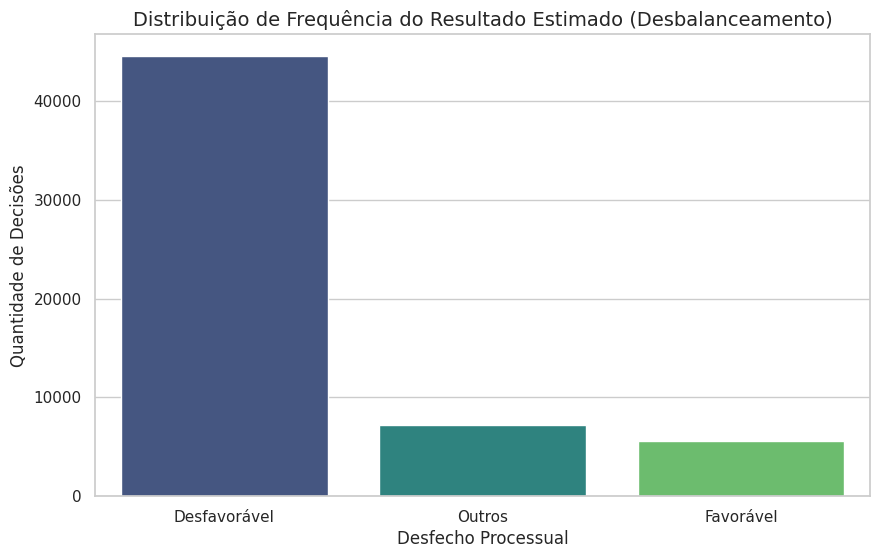



3. COMPORTAMENTO DOS MINISTROS (Cruzamento Ministro vs Resultado)
Resultado_Estimado            Desfavorável  Favorável  Outros
NM_MINISTRO                                                  
AFRÂNIO VILELA                       76.09      11.59   12.32
BENEDITO GONÇALVES                   80.63       8.62   10.75
FRANCISCO FALCÃO                     82.57       8.23    9.20
GURGEL DE FARIA                      80.36      10.23    9.41
MARCO AURÉLIO BELLIZZE               77.32      11.66   11.02
MARIA THEREZA DE ASSIS MOURA         86.50       4.55    8.95
PAULO SÉRGIO DOMINGUES               76.74      13.66    9.59
REGINA HELENA COSTA                  62.28       6.75   30.97
TEODORO SILVA SANTOS                 79.43      10.03   10.54


<Figure size 1000x600 with 0 Axes>

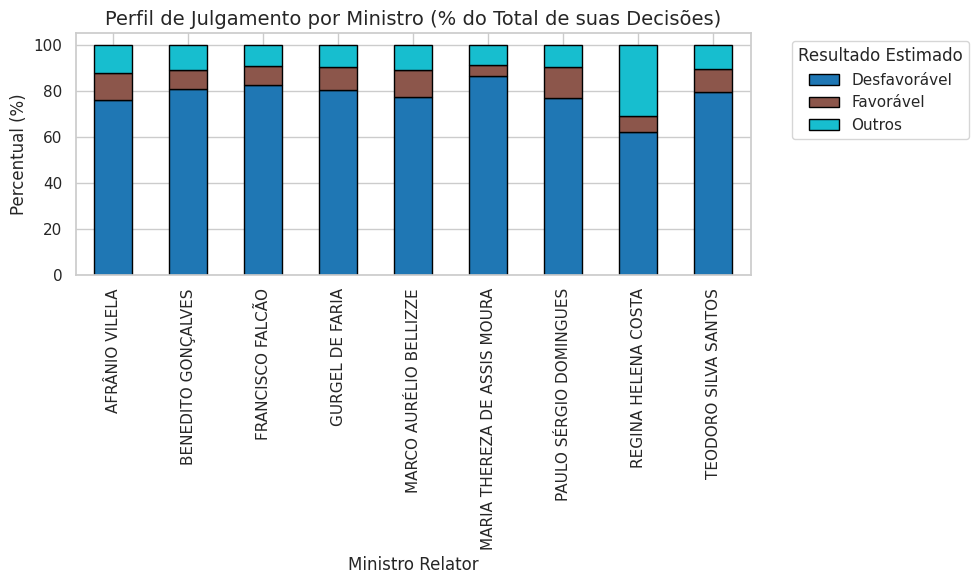



4. TENDÊNCIA DE SUCESSO POR ASSUNTO DO CNJ
Taxa de sucesso nos 10 assuntos mais frequentes (%):
assuntos_nomeados
DIREITO AMBIENTAL                                              15.19
Contribuições Previdenciárias                                  14.42
Intervenção do Estado na Propriedade                           13.87
Benefícios em Espécie                                          13.34
Extinção do Crédito Tributário                                 13.17
DIREITO PREVIDENCIÁRIO                                         12.89
Dívida Ativa não-tributária                                    12.57
Contribuições                                                  11.99
IRPJ/Imposto de Renda de Pessoa Jurídica                       11.82
Base de Cálculo                                                11.80
Cofins                                                         11.79
Contribuições Sociais                                          11.60
PIS                                                     

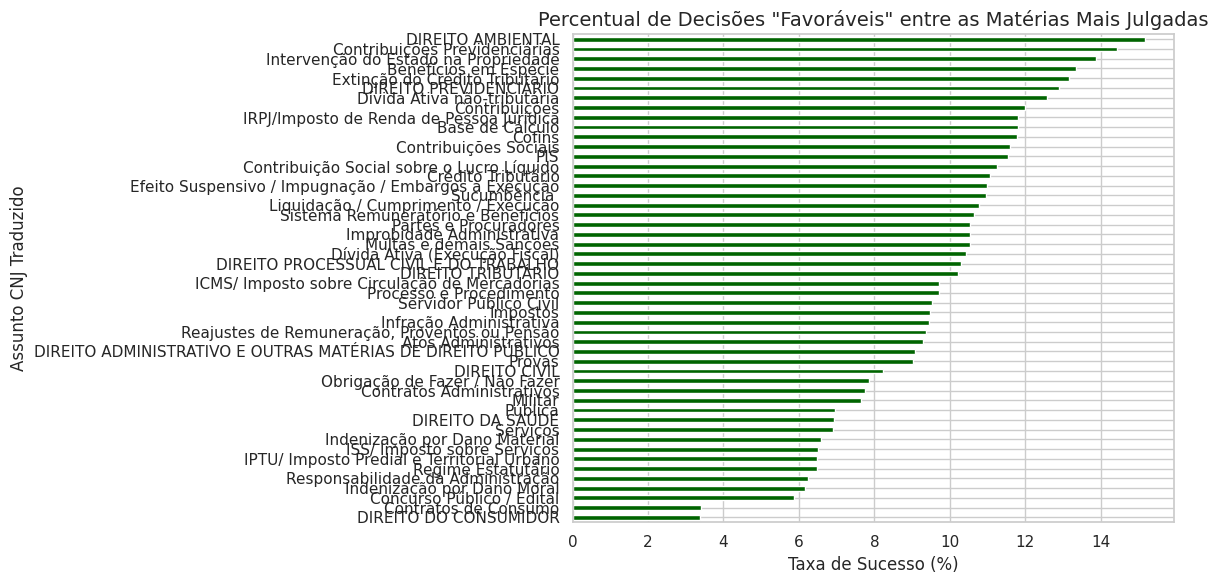

In [ ]:

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("="*60)
print("1. ANÁLISE DE VALORES FALTANTES (MISSING VALUES)")
print("="*60)
# Calcula a quantidade e o percentual de nulos por coluna
valores_nulos = df.isnull().sum()
percentual_nulos = (df.isnull().sum() / len(df)) * 100

df_missing = pd.DataFrame({'Total Nulos': valores_nulos, 'Percentual (%)': percentual_nulos})
print(df_missing[df_missing['Total Nulos'] > 0]) # Mostra apenas colunas com nulos
print("\n")


print("="*60)
print("2. AVALIAÇÃO DE DESBALANCEAMENTO DE CLASSES (Resultado Estimado)")
print("="*60)
# Contagem de frequência das classes de desfecho
contagem_classes = df['Resultado_Estimado'].value_counts()
percentual_classes = df['Resultado_Estimado'].value_counts(normalize=True) * 100

for classe, qtd, pct in zip(contagem_classes.index, contagem_classes.values, percentual_classes.values):
    print(f"Classe '{classe}': {qtd} processos ({pct:.2f}%)")

# Gráfico de Barras do Desbalanceamento
plt.figure()
sns.countplot(data=df, x='Resultado_Estimado', order=contagem_classes.index, palette='viridis')
plt.title('Distribuição de Frequência do Resultado Estimado (Desbalanceamento)')
plt.xlabel('Desfecho Processual')
plt.ylabel('Quantidade de Decisões')
plt.show()
print("\n")


print("="*60)
print("3. COMPORTAMENTO DOS MINISTROS (Cruzamento Ministro vs Resultado)")
print("="*60)
# Tabela cruzada percentual (proporção de decisões por Ministro)
ct_ministros = pd.crosstab(df['NM_MINISTRO'], df['Resultado_Estimado'], normalize='index') * 100
print(ct_ministros.round(2))

# Gráfico de Barras Empilhadas para Comparação entre Ministros
plt.figure()
ct_ministros.plot(kind='bar', stacked=True, cmap='tab10', edgecolor='black')
plt.title('Perfil de Julgamento por Ministro (% do Total de suas Decisões)')
plt.xlabel('Ministro Relator')
plt.ylabel('Percentual (%)')
plt.legend(title='Resultado Estimado', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
print("\n")


print("="*60)
print("4. TENDÊNCIA DE SUCESSO POR ASSUNTO DO CNJ")
print("="*60)
# Create a temporary DataFrame by exploding the 'assuntos_nomeados' column
# This creates a new row for each subject within a list
df_exploded_assuntos = df.explode('assuntos_nomeados')

# Use the exploded DataFrame to get the top 10 most frequent subjects
top_assuntos = df_exploded_assuntos['assuntos_nomeados'].value_counts().head(50).index

# Filter the exploded DataFrame to include only rows with these top subjects
df_top_assuntos_filtered = df_exploded_assuntos[df_exploded_assuntos['assuntos_nomeados'].isin(top_assuntos)]

# Create the crosstab using the filtered exploded DataFrame
ct_assuntos = pd.crosstab(df_top_assuntos_filtered['assuntos_nomeados'], df_top_assuntos_filtered['Resultado_Estimado'], normalize='index') * 100
print("Taxa de sucesso nos 10 assuntos mais frequentes (%):")
print(ct_assuntos['Favorável'].sort_values(ascending=False).round(2))

# Gráfico de linhas ou barras horizontais para os assuntos mais favoráveis
plt.figure(figsize=(12, 6))
ct_assuntos['Favorável'].sort_values(ascending=True).plot(kind='barh', color='darkgreen')
plt.title('Percentual de Decisões "Favoráveis" entre as Matérias Mais Julgadas')
plt.xlabel('Taxa de Sucesso (%)')
plt.ylabel('Assunto CNJ Traduzido')
plt.tight_layout()
plt.show()

In [ ]:
# 1. Filtrar o DataFrame pelas condições da anomalia identificada
# Usamos .str.contains para garantir que pegamos variações como 'MINISTRA REGINA HELENA COSTA'
df_anomalia = df[
    (df['NM_MINISTRO'].str.upper().str.contains('REGINA HELENA')) &
    (df['Resultado_Estimado'] == 'Outros')
]

# 2. Selecionar apenas as colunas de identificação e o teor para análise descritiva
# Usamos .drop_duplicates() se quiser ver apenas os tipos de textos únicos sem repetição
tabela_teor_anomalia = df_anomalia[['processo', 'tipoDocumento', 'teor', 'descricaoMonocratica']].reset_index(drop=True)

# 3. Configurar o Pandas para não cortar o texto longo na exibição da tabela
import pandas as pd
pd.set_option('display.max_colwidth', None)

# 4. Exibir a tabela na tela
print(f"Quantidade de processos mapeados como 'Outros' para a Min. Regina Helena: {len(tabela_teor_anomalia)}")
print("-" * 80)
display(tabela_teor_anomalia)

Quantidade de processos mapeados como 'Outros' para a Min. Regina Helena: 1996
--------------------------------------------------------------------------------


,processo,tipoDocumento,teor,descricaoMonocratica
0,REsp 2256535,DECISÃO,Outros,Conheço do agravo de #{nome_da_parte} para determinar sua autuação como Recurso Especial #{campo_livre_final}
1,REsp 2256501,DECISÃO,Outros,Conheço do agravo de #{nome_da_parte} para determinar sua autuação como Recurso Especial #{campo_livre_final}
2,REsp 2256529,DECISÃO,Outros,Conheço do agravo de #{nome_da_parte} para determinar sua autuação como Recurso Especial #{campo_livre_final}
3,REsp 2250117,DECISÃO,Outros,NaN
4,REsp 2256506,DECISÃO,Outros,Conheço do agravo de #{nome_da_parte} para determinar sua autuação como Recurso Especial #{campo_livre_final}
...,...,...,...,...
1991,REsp 2276568,DECISÃO,Outros,Conheço do agravo de #{nome_da_parte} para determinar sua autuação como Recurso Especial #{campo_livre_final}
1992,REsp 2276561,DECISÃO,Outros,Conheço do agravo de #{nome_da_parte} para determinar sua autuação como Recurso Especial #{campo_livre_final}
1993,REsp 2275013,DECISÃO,Outros,NaN
1994,REsp 2276546,DECISÃO,Outros,Conheço do agravo de #{nome_da_parte} para determinar sua autuação como Recurso Especial #{campo_livre_final}


VOLUMETRIA DE DECISÕES DE MÉRITO POR MINISTRO
Resultado_Estimado            Desfavorável  Favorável  Total Geral
NM_MINISTRO                                                       
AFRÂNIO VILELA                        5405        823         6228
BENEDITO GONÇALVES                    4554        487         5041
FRANCISCO FALCÃO                      3823        381         4204
GURGEL DE FARIA                       4508        574         5082
MARCO AURÉLIO BELLIZZE                5506        830         6336
MARIA THEREZA DE ASSIS MOURA          5556        292         5848
PAULO SÉRGIO DOMINGUES                7072       1259         8331
REGINA HELENA COSTA                   4014        435         4449
TEODORO SILVA SANTOS                  4077        515         4592
Total Geral                          44515       5596        50111



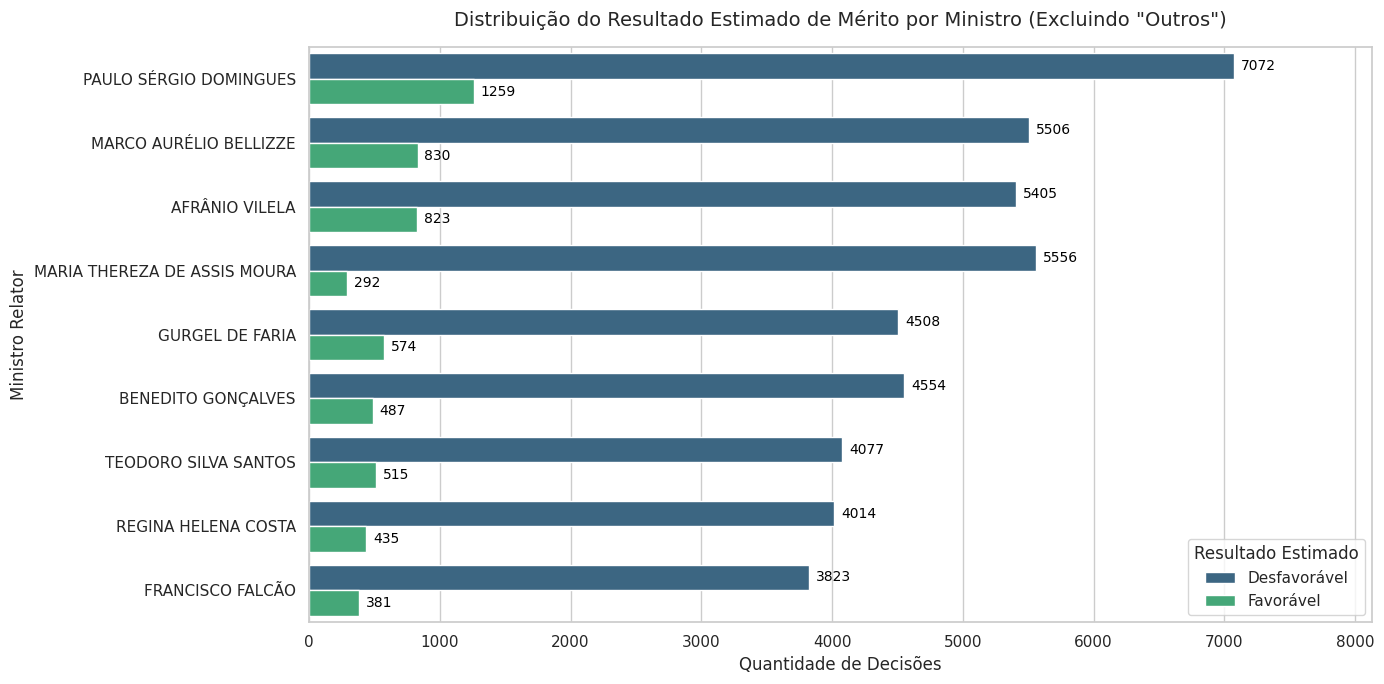

In [ ]:

# =====================================================================
# 1. FILTRAR OS DADOS (Mantendo Ministros e excluindo 'Outros')
# =====================================================================
# Criamos o sub-dataframe de mérito preservando todas as colunas originais (incluindo NM_MINISTRO)
df_merito = df[df['Resultado_Estimado'] != 'Outros'].copy()

# =====================================================================
# 2. EXIBIR ESTATÍSTICA DE MÉRITO POR MINISTRO (Tabela)
# =====================================================================
print("="*60)
print("VOLUMETRIA DE DECISÕES DE MÉRITO POR MINISTRO")
print("="*60)
# Cria uma tabela cruzada para ver a quantidade exata de cada classe por Ministro
tabela_ministro_merito = pd.crosstab(
    df_merito['NM_MINISTRO'],
    df_merito['Resultado_Estimado'],
    margins=True,
    margins_name="Total Geral"
)
print(tabela_ministro_merito)
print("="*60 + "\n")

# =====================================================================
# 3. GERAÇÃO DO GRÁFICO DE BARRAS AGRUPADO
# =====================================================================
plt.figure(figsize=(14, 7))

# Criamos o gráfico de contagem cruzando os Ministros com os Resultados de mérito
ax = sns.countplot(
    data=df_merito,
    y='NM_MINISTRO',
    hue='Resultado_Estimado',
    order=df_merito['NM_MINISTRO'].value_counts().index, # Ordena pelos Ministros com mais processos de mérito
    palette='viridis'
)

# Adiciona os rótulos numéricos nas barras horizontais para facilitar a leitura
for p in ax.patches:
    largura = p.get_width()
    if largura > 0: # Só coloca número se a barra tiver valor
        ax.annotate(
            f'{int(largura)}',
            (largura, p.get_y() + p.get_height() / 2.),
            ha='left',
            va='center',
            fontsize=10,
            color='black',
            xytext=(5, 0),
            textcoords='offset points'
        )

# Configurações de layout
plt.title('Distribuição do Resultado Estimado de Mérito por Ministro (Excluindo "Outros")', fontsize=14, pad=15)
plt.xlabel('Quantidade de Decisões', fontsize=12)
plt.ylabel('Ministro Relator', fontsize=12)
plt.legend(title='Resultado Estimado', loc='lower right')

# Ajusta o limite do eixo X para os números não sumirem na borda direita
plt.xlim(0, df_merito.groupby(['NM_MINISTRO', 'Resultado_Estimado']).size().max() * 1.15)
plt.tight_layout()
plt.show()

In [ ]:


# =====================================================================
# 1. PREPARAÇÃO CRONOLÓGICA DOS DADOS
# =====================================================================
# Garante que a coluna de data esteja no formato correto (datetime)
df['dataPublicacao'] = pd.to_datetime(df['dataPublicacao'])

# Ordena o dataframe por processo e por data (da mais antiga para a mais recente)
df_cronologico = df.sort_values(by=['processo', 'dataPublicacao'], ascending=True).copy()

# =====================================================================
# 2. CAPTURAR A PRIMEIRA E A ÚLTIMA DECISÃO DE CADA PROCESSO
# =====================================================================
# Agrupa por processo e extrai o primeiro registro (Primeira Decisão)
primeira_decisao = df_cronologico.groupby('processo').first().reset_index()
primeira_decisao = primeira_decisao[['processo', 'NM_MINISTRO', 'Resultado_Estimado']].rename(
    columns={'Resultado_Estimado': 'Resultado_Inicial'}
)

# Agrupa por processo e extrai o último registro (Desfecho Atual/Final)
ultima_decisao = df_cronologico.groupby('processo').last().reset_index()
ultima_decisao = ultima_decisao[['processo', 'Resultado_Estimado']].rename(
    columns={'Resultado_Estimado': 'Resultado_Final'}
)

# Cruza as duas informações em um novo DataFrame de análise de mutação
df_mutacao = pd.merge(primeira_decisao, ultima_decisao, on='processo')

# =====================================================================
# 3. FILTRAR PROCESSOS QUE SOFRERAM ALTERAÇÃO DE RESULTADO
# =====================================================================
# Identifica onde o resultado final mudou em relação ao inicial
df_alterados = df_mutacao[df_mutacao['Resultado_Inicial'] != df_mutacao['Resultado_Final']].copy()

# =====================================================================
# 4. EXIBIR RELATÓRIO DA VOLUMETRIA DE MUTAÇÃO JURISPRUDENCIAL
# =====================================================================
total_processos = len(df_mutacao)
total_alterados = len(df_alterados)
percentual_alteracao = (total_alterados / total_processos) * 100

print("="*60)
print("ANÁLISE DE ALTERAÇÃO DE RESULTADO (MUTAÇÃO DO JULGADO)")
print("="*60)
print(f"Total de processos analisados: {total_processos}")
print(f"Processos que MUDARAM de resultado ao longo do tempo: {total_alterados}")
print(f"Percentual de processos que sofreram mutação: {percentual_alteracao:.2f}%\n")

print("="*60)
print("MATRIZ DE TRANSIÇÃO: DE ONDE PARA ONDE OS RESULTADOS MUDARAM?")
print("="*60)
# Mostra a contagem exata das mudanças (Ex: de Desfavorável para Favorável)
matriz_transicao = df_alterados.groupby(['Resultado_Inicial', 'Resultado_Final']).size().reset_index(name='Quantidade')
print(matriz_transicao.to_string(index=False))
print("\n")

print("="*60)
print("RANKING DE ALTERAÇÃO DE RESULTADOS POR MINISTRO")
print("="*60)
# Identifica quais gabinetes possuem maior incidência de reforma/mutação de suas próprias decisões
ranking_ministros = df_alterados.groupby('NM_MINISTRO').size().reset_index(name='Qtd_Alteracoes')
ranking_ministros = ranking_ministros.sort_values(by='Qtd_Alteracoes', ascending=False)
print(ranking_ministros.to_string(index=False))

ANÁLISE DE ALTERAÇÃO DE RESULTADO (MUTAÇÃO DO JULGADO)
Total de processos analisados: 51865
Processos que MUDARAM de resultado ao longo do tempo: 1757
Percentual de processos que sofreram mutação: 3.39%

MATRIZ DE TRANSIÇÃO: DE ONDE PARA ONDE OS RESULTADOS MUDARAM?
Resultado_Inicial Resultado_Final  Quantidade
     Desfavorável       Favorável         151
     Desfavorável          Outros         371
        Favorável    Desfavorável         304
        Favorável          Outros          68
           Outros    Desfavorável         735
           Outros       Favorável         128


RANKING DE ALTERAÇÃO DE RESULTADOS POR MINISTRO
                 NM_MINISTRO  Qtd_Alteracoes
         REGINA HELENA COSTA             825
      MARCO AURÉLIO BELLIZZE             175
              AFRÂNIO VILELA             168
          BENEDITO GONÇALVES             121
MARIA THEREZA DE ASSIS MOURA             118
      PAULO SÉRGIO DOMINGUES              92
        TEODORO SILVA SANTOS              90
  

DIAGNÓSTICO DE DUPLICIDADE EM DECISÕES DE MÉRITO (EXCLUINDO 'OUTROS')
Total de processos únicos com decisões de mérito: 46192
Processos com MAIS DE UMA decisão de mérito no dataset: 3683
Percentual de processos com múltiplas decisões de mérito: 7.97%

QUANTIDADE DE PROCESSOS COM MÚLTIPLAS DECISÕES DE MÉRITO POR MINISTRO
                              total_processos_afetados  \
NM_MINISTRO                                              
MARIA THEREZA DE ASSIS MOURA                       663   
MARCO AURÉLIO BELLIZZE                             642   
BENEDITO GONÇALVES                                 445   
AFRÂNIO VILELA                                     413   
REGINA HELENA COSTA                                402   
GURGEL DE FARIA                                    287   
PAULO SÉRGIO DOMINGUES                             282   
TEODORO SILVA SANTOS                               278   
FRANCISCO FALCÃO                                   271   

                              media_dec

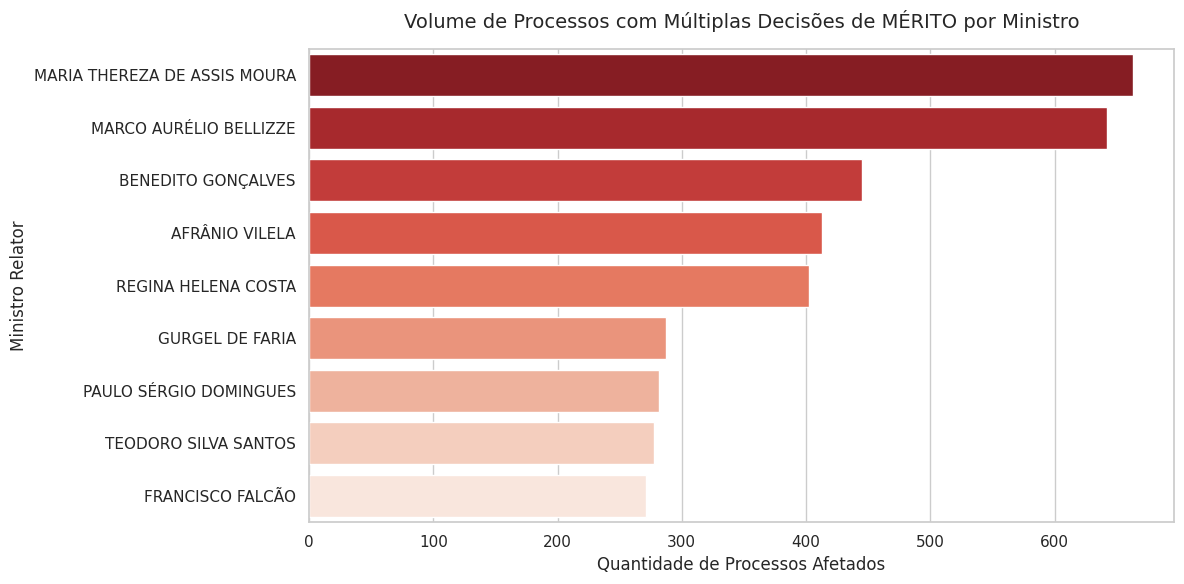

In [ ]:


# =====================================================================
# 1. DIAGNÓSTICO DE MÚLTIPLAS DECISÕES DE MÉRITO POR PROCESSO
# =====================================================================
# Conta quantas decisões de mérito existem para cada combinação de Ministro e Processo usando 'df_merito'
df_contagem_merito = df_merito.groupby(['NM_MINISTRO', 'processo']).size().reset_index(name='qtd_decisoes')

# Filtra apenas as ocorrências onde há mais de uma decisão de mérito registrada para o mesmo processo
df_multiplas_merito = df_contagem_merito[df_contagem_merito['qtd_decisoes'] > 1]

# =====================================================================
# 2. EXIBIR RESUMO ESTATÍSTICO GLOBAL (APENAS MÉRITO)
# =====================================================================
total_proc_unicos_merito = df_contagem_merito['processo'].nunique()
total_proc_multiplos_merito = df_multiplas_merito['processo'].nunique()
percentual_multiplos_merito = (total_proc_multiplos_merito / total_proc_unicos_merito) * 100

print("="*60)
print("DIAGNÓSTICO DE DUPLICIDADE EM DECISÕES DE MÉRITO (EXCLUINDO 'OUTROS')")
print("="*60)
print(f"Total de processos únicos com decisões de mérito: {total_proc_unicos_merito}")
print(f"Processos com MAIS DE UMA decisão de mérito no dataset: {total_proc_multiplos_merito}")
print(f"Percentual de processos com múltiplas decisões de mérito: {percentual_multiplos_merito:.2f}%\n")

# =====================================================================
# 3. TABELA CRUZADA: VOLUMETRIA DE REPETIÇÕES DE MÉRITO POR GABINETE
# =====================================================================
print("="*60)
print("QUANTIDADE DE PROCESSOS COM MÚLTIPLAS DECISÕES DE MÉRITO POR MINISTRO")
print("="*60)
# Agrupa os processos duplicados por ministro para mapear o impacto real em cada gabinete
resumo_ministros_merito = df_multiplas_merito.groupby('NM_MINISTRO').agg(
    total_processos_afetados=('processo', 'count'),
    media_decisoes_por_processo=('qtd_decisoes', 'mean'),
    max_decisoes_num_unico=('qtd_decisoes', 'max')
).sort_values(by='total_processos_afetados', ascending=False)

print(resumo_ministros_merito.round(2))
print("\n")

# =====================================================================
# 4. VISUALIZAÇÃO GRÁFICA DO COMPORTAMENTO POR GABINETE
# =====================================================================
plt.figure(figsize=(12, 6))

# Gerando o gráfico com a sintaxe corrigida para evitar o FutureWarning do Seaborn
sns.barplot(
    data=resumo_ministros_merito.reset_index(),
    x='total_processos_afetados',
    y='NM_MINISTRO',
    hue='NM_MINISTRO',
    palette='Reds_r',
    legend=False
)

plt.title('Volume de Processos com Múltiplas Decisões de MÉRITO por Ministro', fontsize=14, pad=15)
plt.xlabel('Quantidade de Processos Afetados', fontsize=12)
plt.ylabel('Ministro Relator', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# =====================================================================
# 1. FILTRAGEM DE MÉRITO E PREPARAÇÃO CRONOLÓGICA
# =====================================================================
# Filtra o dataframe original para remover a classe 'Outros'
df_merito_mutacao = df[df['Resultado_Estimado'] != 'Outros'].copy()

# Garante que a coluna de data esteja no formato correto (datetime)
df_merito_mutacao['dataPublicacao'] = pd.to_datetime(df_merito_mutacao['dataPublicacao'])

# Ordena o dataframe por processo e por data (da decisão mais antiga para a mais recente)
df_cronologico_merito = df_merito_mutacao.sort_values(by=['processo', 'dataPublicacao'], ascending=True).copy()

# =====================================================================
# 2. CAPTURAR A PRIMEIRA E A ÚLTIMA DECISÃO DE MÉRITO DE CADA PROCESSO
# =====================================================================
# Agrupa por processo e extrai o primeiro registro de mérito (Primeira Decisão de Mérito)
primeira_decisao_merito = df_cronologico_merito.groupby('processo').first().reset_index()
primeira_decisao_merito = primeira_decisao_merito[['processo', 'NM_MINISTRO', 'Resultado_Estimado']].rename(
    columns={'Resultado_Estimado': 'Resultado_Inicial_Mérito'}
)

# Agrupa por processo e extrai o último registro de mérito (Desfecho Final de Mérito)
ultima_decisao_merito = df_cronologico_merito.groupby('processo').last().reset_index()
ultima_decisao_merito = ultima_decisao_merito[['processo', 'Resultado_Estimado']].rename(
    columns={'Resultado_Estimado': 'Resultado_Final_Mérito'}
)

# Cruza as duas informações em um novo DataFrame focado na mutação de mérito
df_mutacao_merito = pd.merge(primeira_decisao_merito, ultima_decisao_merito, on='processo')

# =====================================================================
# 3. FILTRAR PROCESSOS QUE SOFRERAM ALTERAÇÃO DE MÉRITO
# =====================================================================
# Identifica onde o resultado de mérito final mudou em relação ao inicial de mérito
df_alterados_merito = df_mutacao_merito[
    df_mutacao_merito['Resultado_Inicial_Mérito'] != df_mutacao_merito['Resultado_Final_Mérito']
].copy()

# =====================================================================
# 4. EXIBIR RELATÓRIO DA VOLUMETRIA DE MUTAÇÃO DE MÉRITO
# =====================================================================
total_proc_merito = len(df_mutacao_merito)
total_alterados_merito = len(df_alterados_merito)
percentual_alteracao_merito = (total_alterados_merito / total_proc_merito) * 100 if total_proc_merito > 0 else 0

print("="*60)
print("ANÁLISE DE MUTAÇÃO DO JULGADO (APENAS DECISÕES DE MÉRITO)")
print("="*60)
print(f"Total de processos com decisões de mérito analisados: {total_proc_merito}")
print(f"Processos que MUDARAM de mérito ao longo do tempo: {total_alterados_merito}")
print(f"Percentual de real mutação de mérito na Corte: {percentual_alteracao_merito:.2f}%\n")

if total_alterados_merito > 0:
    print("="*60)
    print("MATRIZ DE TRANSIÇÃO DE MÉRITO: DE ONDE PARA ONDE OS PLACARES VIRARAM?")
    print("="*60)
    # Mostra a contagem exata das mudanças de mérito (Ex: de Favorável para Desfavorável)
    matriz_transicao_merito = df_alterados_merito.groupby(['Resultado_Inicial_Mérito', 'Resultado_Final_Mérito']).size().reset_index(name='Quantidade')
    print(matriz_transicao_merito.to_string(index=False))
    print("\n")

    print("="*60)
    print("RANKING DE ALTERAÇÃO DE MÉRITO POR MINISTRO")
    print("="*60)
    # Identifica quais gabinetes alteraram mais decisões de mérito próprias
    ranking_ministros_merito = df_alterados_merito.groupby('NM_MINISTRO').size().reset_index(name='Qtd_Alteracoes')
    ranking_ministros_merito = ranking_ministros_merito.sort_values(by='Qtd_Alteracoes', ascending=False)
    print(ranking_ministros_merito.to_string(index=False))

ANÁLISE DE MUTAÇÃO DO JULGADO (APENAS DECISÕES DE MÉRITO)
Total de processos com decisões de mérito analisados: 46192
Processos que MUDARAM de mérito ao longo do tempo: 471
Percentual de real mutação de mérito na Corte: 1.02%

MATRIZ DE TRANSIÇÃO DE MÉRITO: DE ONDE PARA ONDE OS PLACARES VIRARAM?
Resultado_Inicial_Mérito Resultado_Final_Mérito  Quantidade
            Desfavorável              Favorável         158
               Favorável           Desfavorável         313


RANKING DE ALTERAÇÃO DE MÉRITO POR MINISTRO
                 NM_MINISTRO  Qtd_Alteracoes
      MARCO AURÉLIO BELLIZZE              99
              AFRÂNIO VILELA              71
          BENEDITO GONÇALVES              54
         REGINA HELENA COSTA              49
        TEODORO SILVA SANTOS              44
             GURGEL DE FARIA              43
MARIA THEREZA DE ASSIS MOURA              41
            FRANCISCO FALCÃO              38
      PAULO SÉRGIO DOMINGUES              32


### Filtrando por 'Direito Tributário' e Análise Exploratória

Vamos agora aplicar um filtro para selecionar apenas os processos relacionados a 'Direito Tributário' e comparar as decisões por tipo de documento, recurso e resultado estimado.

In [ ]:
# Filtrar processos que contêm 'Direito Tributário' em 'assuntos_nomeados'
df_tributario = df[df['assuntos_nomeados'].apply(lambda x: 'DIREITO TRIBUTÁRIO' in x if isinstance(x, list) else False)].copy()

print(f"Total de decisões na 1ª Seção: {len(df)}")
print(f"Total de decisões de Direito Tributário na 1ª Seção: {len(df_tributario)}")

print("\nDistribuição de decisões de Direito Tributário por Tipo de Documento:")
display(df_tributario['tipoDocumento'].value_counts())

print("\nDistribuição de decisões de Direito Tributário por Recurso:")
display(df_tributario['recurso'].value_counts(dropna=False))

print("\nDistribuição de decisões de Direito Tributário por Resultado Estimado:")
display(df_tributario['Resultado_Estimado'].value_counts())

print("\nDistribuição cruzada de Tipo de Documento, Recurso e Resultado Estimado para Direito Tributário:")
display(df_tributario.groupby(['tipoDocumento', 'recurso', 'Resultado_Estimado'], dropna=False).size().unstack(fill_value=0))

Total de decisões na 1ª Seção: 57328
Total de decisões de Direito Tributário na 1ª Seção: 19578

Distribuição de decisões de Direito Tributário por Tipo de Documento:


,count
tipoDocumento,
DECISÃO,12475
ACÓRDÃO,7103



Distribuição de decisões de Direito Tributário por Recurso:


,count
recurso,
NaN,11315
AgInt,5498
EDcl,2353
DESIS,237
PET,90
AgRg,32
ProAfR,23
Acordo,9
RCD,9



Distribuição de decisões de Direito Tributário por Resultado Estimado:


,count
Resultado_Estimado,
Desfavorável,15231
Outros,2347
Favorável,2000



Distribuição cruzada de Tipo de Documento, Recurso e Resultado Estimado para Direito Tributário:


Resultado_Estimado     Desfavorável  Favorável  Outros
tipoDocumento recurso                                 
ACÓRDÃO       AgInt            4731         39       0
              AgRg                7         25       0
              DESIS               0          0       2
              EDcl             1444          0     120
              PET                 1          0       0
              ProAfR              0          0      23
              RCD                 3          0       0
              RE                  0          2       0
              NaN               612         92       2
DECISÃO       Acordo              0          1       8
              AgInt             193        110     425
              DESIS              51          0     184
              EDcl              592        152      45
              PDist               2          0       2
              PET                19          2      68
              RCD                 4          0       2
              RtPaut              0          0       5
              TutPrv              1          0       0
              NaN              7571       1577    1461

### Ministros com 'ACÓRDÃO' e 'Recurso' Nulo em 'Direito Tributário'

Vamos agora identificar os ministros responsáveis por decisões do tipo 'ACÓRDÃO' onde o campo 'recurso' não foi preenchido, especificamente dentro do contexto de 'Direito Tributário'.

In [ ]:
# Filtrar o DataFrame df_tributario para 'tipoDocumento' == 'ACÓRDÃO' e 'recurso' é nulo
ministros_acordao_nan_recurso = df_tributario[
    (df_tributario['tipoDocumento'] == 'ACÓRDÃO') &
    (df_tributario['recurso'].isna())
]

print("Ministros com 'tipoDocumento' = ACÓRDÃO e 'recurso' = NaN (Direito Tributário):")

counts = ministros_acordao_nan_recurso[['NM_MINISTRO', 'Resultado_Estimado']].value_counts()
percentages = ministros_acordao_nan_recurso.groupby('NM_MINISTRO')['Resultado_Estimado'].value_counts(normalize=True).mul(100)

result_df = pd.DataFrame({'Qtde': counts, 'Percentual': percentages.round(2)})
display(result_df)

Ministros com 'tipoDocumento' = ACÓRDÃO e 'recurso' = NaN (Direito Tributário):


Qtde  Percentual
NM_MINISTRO                  Resultado_Estimado                  
AFRÂNIO VILELA               Desfavorável          23       79.31
                             Favorável              6       20.69
BENEDITO GONÇALVES           Desfavorável           1      100.00
FRANCISCO FALCÃO             Desfavorável         277       97.88
                             Favorável              6        2.12
GURGEL DE FARIA              Desfavorável           4       50.00
                             Favorável              4       50.00
MARCO AURÉLIO BELLIZZE       Desfavorável           8       53.33
                             Favorável              7       46.67
MARIA THEREZA DE ASSIS MOURA Desfavorável          41       56.94
                             Favorável             29       40.28
                             Outros                 2        2.78
PAULO SÉRGIO DOMINGUES       Desfavorável           5       62.50
                             Favorável              3       37.50
REGINA HELENA COSTA          Desfavorável           1       50.00
                             Favorável              1       50.00
TEODORO SILVA SANTOS         Desfavorável         252       87.50
                             Favorável             36       12.50

In [ ]:
# Filtrar o DataFrame df_tributario para 'tipoDocumento' == 'DECISÃO'
ministros_decisao_nan_recurso = df_tributario[
    (df_tributario['tipoDocumento'] == 'DECISÃO')
]

print("Ministros com 'tipoDocumento' = DECISÃO (Direito Tributário):")

counts = ministros_decisao_nan_recurso[['NM_MINISTRO', 'Resultado_Estimado']].value_counts()
percentages = ministros_decisao_nan_recurso.groupby('NM_MINISTRO')['Resultado_Estimado'].value_counts(normalize=True).mul(100)

result_df = pd.DataFrame({'Qtde': counts, 'Percentual': percentages.round(2)})
display(result_df)

Ministros com 'tipoDocumento' = DECISÃO (Direito Tributário):


Qtde  Percentual
NM_MINISTRO                  Resultado_Estimado                  
AFRÂNIO VILELA               Desfavorável         869       63.34
                             Favorável            242       17.64
                             Outros               261       19.02
BENEDITO GONÇALVES           Desfavorável         805       70.55
                             Favorável            193       16.91
                             Outros               143       12.53
FRANCISCO FALCÃO             Desfavorável         412       67.65
                             Favorável            104       17.08
                             Outros                93       15.27
GURGEL DE FARIA              Desfavorável         929       76.84
                             Favorável            155       12.82
                             Outros               125       10.34
MARCO AURÉLIO BELLIZZE       Desfavorável        1466       68.38
                             Favorável            348       16.23
                             Outros               330       15.39
MARIA THEREZA DE ASSIS MOURA Desfavorável         739       77.46
                             Favorável             55        5.77
                             Outros               160       16.77
PAULO SÉRGIO DOMINGUES       Desfavorável        1928       71.89
                             Favorável            485       18.08
                             Outros               269       10.03
REGINA HELENA COSTA          Desfavorável         855       52.01
                             Favorável            133        8.09
                             Outros               656       39.90
TEODORO SILVA SANTOS         Desfavorável         430       59.72
                             Favorável            127       17.64
                             Outros               163       22.64

### Comparação Gráfica dos Resultados Estimados por Tipo de Documento

Vamos agora visualizar e comparar a distribuição percentual dos 'Resultados Estimados' para os documentos do tipo 'ACÓRDÃO' e 'DECISÃO' no contexto de 'Direito Tributário'.

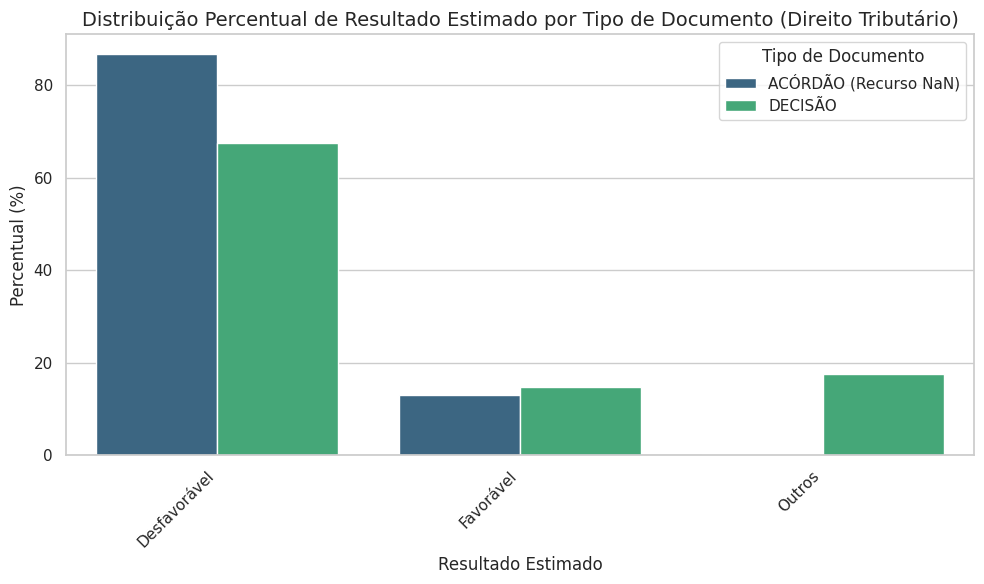

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for 'ACÓRDÃO' (from ministros_acordao_nan_recurso)
# Note: ministros_acordao_nan_recurso is filtered by tipoDocumento == 'ACÓRDÃO' AND recurso.isna()
acordao_overall_percentages = ministros_acordao_nan_recurso['Resultado_Estimado'].value_counts(normalize=True).mul(100).reset_index()
acordao_overall_percentages.columns = ['Resultado_Estimado', 'Percentual']
acordao_overall_percentages['Documento_Tipo'] = 'ACÓRDÃO (Recurso NaN)'

# Prepare data for 'DECISÃO' (from ministros_decisao_nan_recurso)
# Note: ministros_decisao_nan_recurso is filtered ONLY by tipoDocumento == 'DECISÃO'
decisao_overall_percentages = ministros_decisao_nan_recurso['Resultado_Estimado'].value_counts(normalize=True).mul(100).reset_index()
decisao_overall_percentages.columns = ['Resultado_Estimado', 'Percentual']
decisao_overall_percentages['Documento_Tipo'] = 'DECISÃO'

# Combine the dataframes
overall_combined_percentages = pd.concat([acordao_overall_percentages, decisao_overall_percentages])

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Resultado_Estimado', y='Percentual', hue='Documento_Tipo', data=overall_combined_percentages, palette='viridis')
plt.title('Distribuição Percentual de Resultado Estimado por Tipo de Documento (Direito Tributário)')
plt.xlabel('Resultado Estimado')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Tipo de Documento')
plt.tight_layout()
plt.show()